In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [6]:
import os
print(os.getcwd())

/Users/rakhijha/Support-Integrity-Auditor


In [7]:
os.listdir()

['predict.py',
 ' requirements.txt',
 'app.py',
 '.ipynb_checkpoints',
 'data',
 'notebooks',
 'src']

In [9]:
df = pd.read_csv("data/customer_support_tickets.csv")

print(df.shape)
df.head()

(20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


In [10]:
print("Rows, Columns :", df.shape)

Rows, Columns : (20000, 12)


In [11]:
df.columns

Index(['Ticket_ID', 'Customer_Name', 'Customer_Email', 'Ticket_Subject',
       'Ticket_Description', 'Issue_Category', 'Priority_Level',
       'Ticket_Channel', 'Submission_Date', 'Resolution_Time_Hours',
       'Assigned_Agent', 'Satisfaction_Score'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [13]:
df.isnull().sum()

Ticket_ID                0
Customer_Name            0
Customer_Email           0
Ticket_Subject           0
Ticket_Description       0
Issue_Category           0
Priority_Level           0
Ticket_Channel           0
Submission_Date          0
Resolution_Time_Hours    0
Assigned_Agent           0
Satisfaction_Score       0
dtype: int64

In [14]:
df.describe()

,Resolution_Time_Hours,Satisfaction_Score
count,20000.000000,20000.000000
mean,39.230300,3.723700
std,35.221884,1.286989
min,1.000000,1.000000
25%,11.000000,3.000000
50%,27.000000,4.000000
75%,58.000000,5.000000
max,120.000000,5.000000


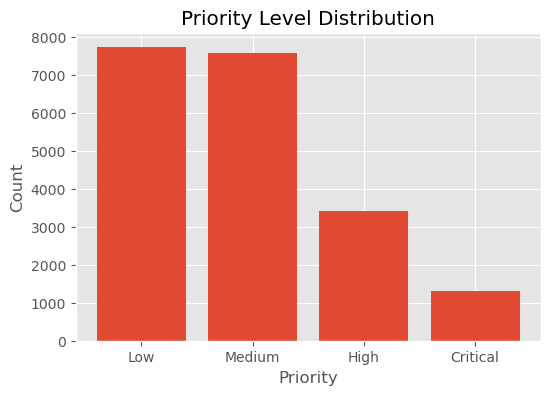

In [15]:
import matplotlib.pyplot as plt

priority_counts = df["Priority_Level"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(priority_counts.index, priority_counts.values)
plt.title("Priority Level Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

In [16]:
df["Priority_Level"].value_counts()

Priority_Level
Low         7716
Medium      7570
High        3416
Critical    1298
Name: count, dtype: int64

In [17]:
priority_percentage = (
    df["Priority_Level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

priority_percentage

Priority_Level
Low         38.58
Medium      37.85
High        17.08
Critical     6.49
Name: proportion, dtype: float64

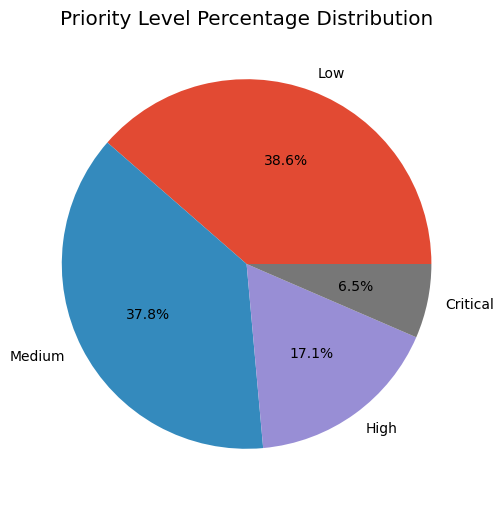

In [18]:
plt.figure(figsize=(6,6))
plt.pie(
    priority_percentage.values,
    labels=priority_percentage.index,
    autopct='%1.1f%%'
)
plt.title("Priority Level Percentage Distribution")
plt.show()

In [19]:
df["Issue_Category"].value_counts()

Issue_Category
Technical          5918
Billing            5036
Account            4081
General Inquiry    3925
Fraud              1040
Name: count, dtype: int64

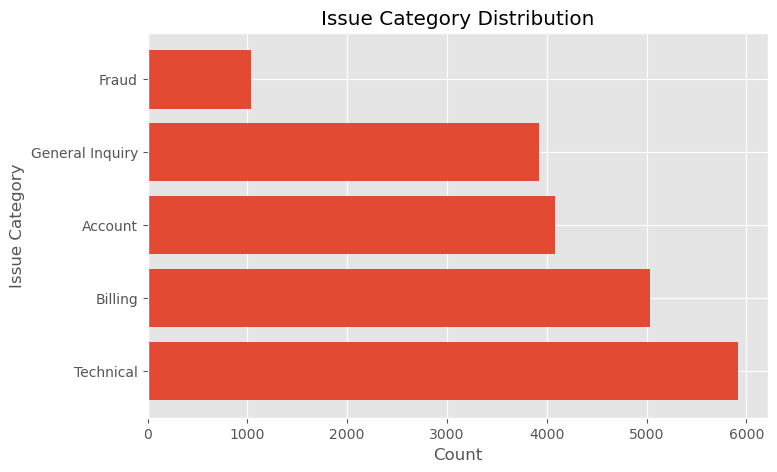

In [20]:
plt.figure(figsize=(8,5))

issue_counts = df["Issue_Category"].value_counts()

plt.barh(issue_counts.index, issue_counts.values)
plt.title("Issue Category Distribution")
plt.xlabel("Count")
plt.ylabel("Issue Category")

plt.show()

In [22]:
### Observation

#- Technical issues are the most common category, accounting for 5918 tickets (~29.6%).
#- Billing-related problems form the second largest group with 5036 tickets.
#- Account issues and General Inquiries occur with similar frequency.
# Fraud-related tickets are relatively rare (1040 samples), comprising only about 5.2% of the dataset.

#The relatively low occurrence of Fraud cases suggests that these tickets may represent higher-severity events and could contribute significantly to the inferred severity score during pseudo-label generation.

In [23]:
(
    df["Issue_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Issue_Category
Technical          29.59
Billing            25.18
Account            20.40
General Inquiry    19.62
Fraud               5.20
Name: proportion, dtype: float64

In [24]:
df["Resolution_Time_Hours"].describe()

count    20000.000000
mean        39.230300
std         35.221884
min          1.000000
25%         11.000000
50%         27.000000
75%         58.000000
max        120.000000
Name: Resolution_Time_Hours, dtype: float64

In [26]:
### Resolution Time Analysis

#The dataset contains 20,000 tickets.
#The average resolution time is approximately **39.23 hours**.
#Half of all tickets are resolved within **27 hours** (median).
#75% of tickets are resolved within **58 hours**.
# The maximum recorded resolution time is **120 hours**.

#The large gap between the median (27 hrs) and the maximum (120 hrs) suggests a right-skewed distribution, indicating the presence of a relatively small number of tickets that require significantly longer resolution times.

<Figure size 800x500 with 0 Axes>

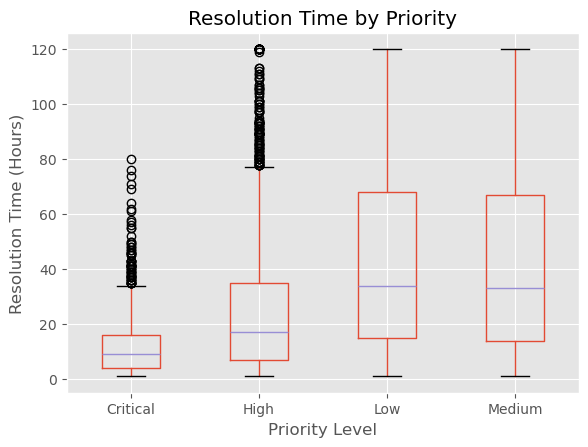

In [25]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Resolution_Time_Hours",
    by="Priority_Level"
)

plt.suptitle("")
plt.title("Resolution Time by Priority")
plt.xlabel("Priority Level")
plt.ylabel("Resolution Time (Hours)")

plt.show()

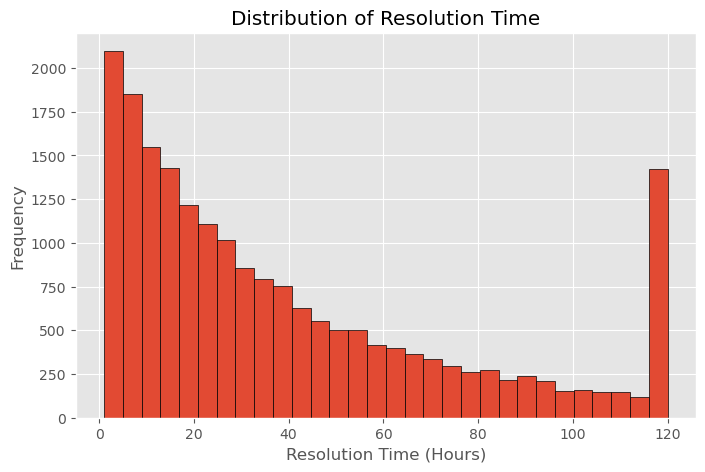

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Resolution_Time_Hours"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")

plt.show()

<Figure size 800x500 with 0 Axes>

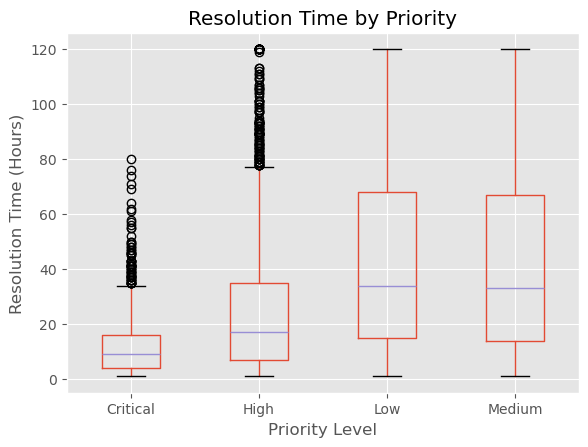

In [28]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Resolution_Time_Hours",
    by="Priority_Level"
)

plt.suptitle("")
plt.title("Resolution Time by Priority")
plt.xlabel("Priority Level")
plt.ylabel("Resolution Time (Hours)")

plt.show()

In [29]:
### Observation

#The relationship between assigned priority and resolution time is not strictly monotonic. Surprisingly, Critical tickets exhibit relatively lower median resolution times compared to Low and Medium priority tickets.

#This behavior may reflect real-world support systems, where highly critical issues receive immediate attention and are resolved faster due to SLA enforcement. Consequently, resolution time alone cannot accurately determine ticket severity and should be combined with semantic and rule-based signals during pseudo-label generation.

In [30]:
df["Subject_Length"] = df["Ticket_Subject"].str.len()
df["Description_Length"] = df["Ticket_Description"].str.len()

df[["Subject_Length", "Description_Length"]].describe()

,Subject_Length,Description_Length
count,20000.000000,20000.00000
mean,23.262450,99.61870
std,3.264675,14.74394
min,14.000000,60.00000
25%,21.000000,89.00000
50%,23.000000,99.00000
75%,25.000000,110.00000
max,37.000000,153.00000


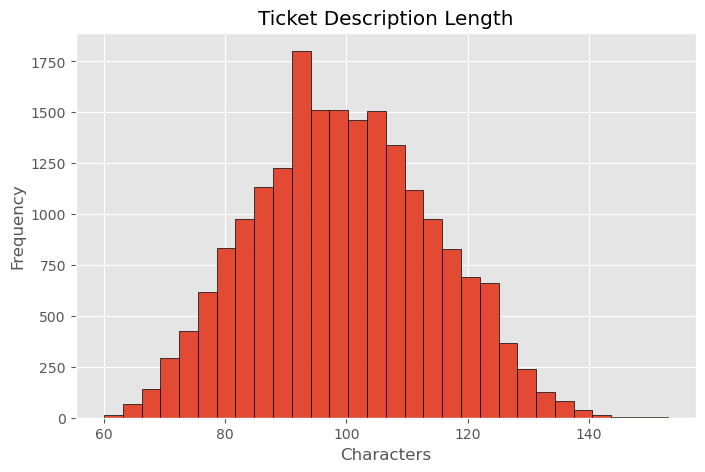

In [31]:
plt.figure(figsize=(8,5))
plt.hist(df["Description_Length"], bins=30, edgecolor="black")
plt.title("Ticket Description Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

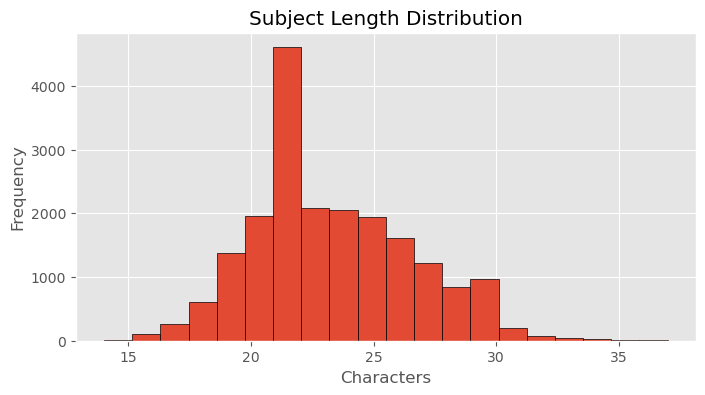

In [32]:
plt.figure(figsize=(8,4))

plt.hist(
    df["Subject_Length"],
    bins=20,
    edgecolor="black"
)

plt.title("Subject Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

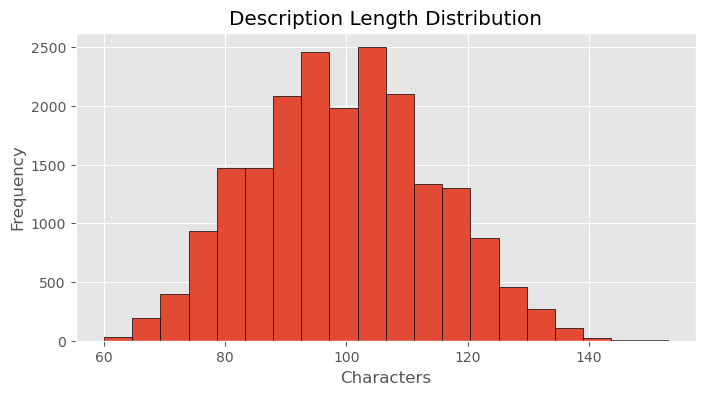

In [33]:
plt.figure(figsize=(8,4))

plt.hist(
    df["Description_Length"],
    bins=20,
    edgecolor="black"
)

plt.title("Description Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [34]:
# Exploratory Data Analysis Summary

#- The dataset contains **20,000 customer support tickets** and **12 features**.
#- No missing values were observed.
#- Priority labels exhibit moderate class imbalance, with Critical tickets representing only about 6.5% of the data.
#- Technical and Billing issues dominate the dataset, while Fraud cases are relatively rare.
#- Resolution time alone does not perfectly correlate with assigned priority, suggesting that severity must be inferred using multiple independent signals.
#- Ticket descriptions contain substantially richer textual information than ticket subjects.
#- The dataset contains both structured and unstructured features, making it well-suited for a hybrid NLP and tabular learning approach.